# Unsupervised Chiral-Basis Solution of the Kitaev-Chain Spectral Problem

## I. Introduction

The Kitaev chain is the minimal model in which a topological superconducting
phase transition and its associated Majorana bound states may be studied by
exact means. In this notebook we construct a physics-informed neural network
that represents the lowest non-negative Bogoliubov--de Gennes (BdG) eigenpair
as a continuous function of the chemical potential $\mu$, and we train it
without recourse to any exactly diagonalised reference data.

The semi-supervised treatment developed elsewhere in this project anchors the
network to a small set of eigenpairs obtained from `numpy.linalg.eigh` and
relies on a four-term loss functional with an annealing schedule that balances
data fidelity against the physics residual. The present approach dispenses
with the labelled data entirely. This is made possible by transferring the
spectral problem to the Majorana basis, in which the chiral symmetry of the
model renders the particle--hole spectral pairing and the normalisation of
the eigenvector exact by construction; the non-negativity of the energy and
the particle/hole assignment of the eigenvector, the one gauge freedom the
objective leaves open, are then fixed by an explicit branch choice at
reconstruction time. The residual that remains to be minimised comprises two
terms of equal, fixed weight and carries no schedule.

## II. Formalism

### A. Bogoliubov--de Gennes Hamiltonian and its symmetries

In the Nambu basis
$\Psi = (c_1,\dots,c_N,c_1^\dagger,\dots,c_N^\dagger)^{\mathsf T}$ the BdG
Hamiltonian of the open Kitaev chain is a real symmetric $2N \times 2N$ matrix
with the block structure

$$
H(\mu) \;=\;
\begin{pmatrix} A(\mu) & B \\[2pt] B^{\mathsf T} & -A(\mu) \end{pmatrix},
\tag{1}
$$

in which $A(\mu)$ carries the on-site potential and the nearest-neighbour
hopping and $B$ the $p$-wave pairing. This representation makes manifest a
single symmetry, particle--hole conjugation
$\Xi\,H(\mu)\,\Xi = -H(\mu)$ with $\Xi = \tau_x \otimes \mathbb{1}_N$. In a
residual formulation this symmetry is redundant: because $\Xi H \Xi = -H$
holds identically, the penalty that would enforce it is numerically equal to
the Schr\"odinger residual at every step and therefore supplies no independent
information.

### B. The Majorana basis

Introducing Majorana operators $a_n = c_n + c_n^\dagger$ and
$b_n = -\mathrm{i}\,(c_n - c_n^\dagger)$ and ordering them by sublattice,
$\gamma = (a_1,\dots,a_N,b_1,\dots,b_N)^{\mathsf T}$, the change of basis is
effected by the fixed unitary

$$
\Omega \;=\; \frac{1}{\sqrt{2}}
\begin{pmatrix}
\mathbb{1} & \mathbb{1} \\[2pt]
-\mathrm{i}\,\mathbb{1} & \mathrm{i}\,\mathbb{1}
\end{pmatrix}.
\tag{2}
$$

Under this transformation the Hamiltonian becomes purely imaginary and
antisymmetric,

$$
\Omega\,H(\mu)\,\Omega^\dagger \;=\; \mathrm{i}\,M(\mu),
\qquad M(\mu)^{\mathsf T} = -M(\mu).
\tag{3}
$$

The eigenvalues of a real antisymmetric matrix occur in conjugate pairs
$\pm\mathrm{i}\lambda_k$ with $\lambda_k \ge 0$, so the spectrum of
$\mathrm{i}M$ is $\{\pm\lambda_k\}$. The particle--hole pairing of the BdG
spectrum is therefore a consequence of the antisymmetry of $M$ rather than a
symmetry that must be imposed on the solution.

### C. Chiral reduction

The real Kitaev chain belongs to symmetry class BDI: it possesses both a
particle--hole and a spinless time-reversal symmetry, each squaring to $+1$,
and hence a chiral symmetry $S = \mathcal{T}\mathcal{C}$ distinct from $\Xi$.
In the sublattice ordering $S$ anticommutes with $M$, which constrains the
latter to the block-off-diagonal form

$$
M(\mu) \;=\;
\begin{pmatrix} 0 & h(\mu) \\[2pt] -h(\mu)^{\mathsf T} & 0 \end{pmatrix}.
\tag{4}
$$

Evaluating the Majorana bilinears of the Kitaev Hamiltonian yields $h(\mu)$
explicitly as the real $N \times N$ bidiagonal matrix

$$
h_{n,n} = -\mu, \qquad
h_{n,n+1} = -(t+\Delta), \qquad
h_{n+1,n} = -(t-\Delta),
\tag{5}
$$

linear in $\mu$. This construction is implemented in
`kitaev.analytical.chiral_block`, and the identity (3)--(4) with $h$ given by
(5) is verified against direct construction of $H(\mu)$ to machine precision
in `tests/analytical/test_majorana.py`.

### D. Spectral correspondence

Let $h(\mu) = U(\mu)\,\mathrm{diag}(\lambda_k)\,V(\mu)^{\mathsf T}$ be the
singular value decomposition, with singular values ordered
$\lambda_1 \le \cdots \le \lambda_N$. The singular values of $h$ coincide with
the non-negative eigenvalues of $H(\mu)$, so the $\pm\lambda$ structure of the
BdG spectrum is exact. Given the smallest singular pair $(u,v)$, normalised
such that $\lVert u \rVert = \lVert v \rVert = 1$, the corresponding
positive-energy eigenvector of $H(\mu)$ in the original Nambu basis is

$$
\psi \;=\; \Big( \tfrac{u+v}{2},\;\; \tfrac{u-v}{2} \Big),
\qquad \lVert \psi \rVert = 1,
\tag{6}
$$

partitioned into particle and hole blocks; its negative-energy partner is the
particle--hole conjugate $\Xi\psi$, obtained by exchanging the two blocks. A
Majorana zero mode corresponds to a vanishing singular value of $h(\mu)$, and
$\lambda_1(\mu) \to 0$ precisely at $|\mu| = 2t$, independent of $\Delta$,
which is the location of the topological transition.

### E. Reflection symmetry in $\mu$

The bidiagonal structure (5) implies $h(-\mu) = -D\,h(\mu)\,D$ with
$D = \mathrm{diag}\!\big((-1)^n\big)$. It follows that
$\lambda_k(-\mu) = \lambda_k(\mu)$ and that the singular vectors transform as
$u(-\mu) = -D\,u(\mu)$ and $v(-\mu) = D\,v(\mu)$. The spectral problem need
therefore be solved only for $\mu \ge 0$; the negative-$\mu$ solution is a
fixed linear image of the positive-$\mu$ one and is obtained without further
training.

## III. Network architecture

The surrogate is a sinusoidal representation network (SIREN). Sinusoidal
activations are adopted because the physics residual differentiates the
network output with respect to $\mu$, and a sine together with all of its
derivatives remains bounded and smooth. A single shared backbone maps the
scalar $|\mu|$, rescaled to $[0,1]$, to a feature vector, from which one
linear head produces the concatenated pair

$$
\mu \;\longmapsto\; \big(u(\mu),\, v(\mu)\big)
\;\in\; \mathbb{R}^N \times \mathbb{R}^N.
\tag{7}
$$

Three properties are enforced within the forward evaluation and are therefore
absent from the loss. First, each half of the head output is normalised to
unit Euclidean length, so that the reconstructed eigenvector (6) is
automatically normalised. Second, the energy is not an output of the network
but the Rayleigh quotient $\lambda_R = u^{\mathsf T} h(\mu)\,v$, a singular
value; the $\pm\lambda$ pairing follows from the construction of Sec. II D.
The loss (8) is invariant under $(u,v) \to (u,-v)$, which negates
$\lambda_R$ and exchanges the reconstructed eigenvector with its
particle--hole partner, so the trained network is free to sit on either
branch and the choice may vary with $\mu$. At reconstruction time
`kitaev.analytical.resolve_singular_branch` removes this freedom: wherever
$\lambda_R$ is safely non-zero it flips $v$ so that $\lambda_R \ge 0$,
which simultaneously fixes the particle/hole assignment of $\psi$; points
with $|\lambda_R| \lesssim 10^{-3}$, the ambiguous near-zero modes of the
topological phase, are left as the network produced them. Third, the
reflection $u \to -D u$, $v \to D v$ is applied whenever $\mu < 0$, so that
the network is only ever evaluated on $|\mu|$ and the spectrum is even in
$\mu$ by construction. The site count passed to the constructor is the
physical value $N$, not the doubled BdG dimension.

## IV. Loss functional

Training minimises the label-free functional

$$
\mathcal{L} \;=\; \mathcal{L}_{\mathrm{fsm}} \;+\; \mathcal{L}_{\mathrm{var}},
\tag{8}
$$

in which the two terms carry equal, fixed weight and no annealing schedule.
The folded-spectrum term

$$
\mathcal{L}_{\mathrm{fsm}} \;=\;
\big\langle \lVert h(\mu)\,v \rVert^2 \big\rangle
\;+\;
\big\langle \lVert h(\mu)^{\mathsf T} u \rVert^2 \big\rangle
\tag{9}
$$

is minimised when $(u,v)$ align with the singular vectors of the smallest
singular value of $h(\mu)$: the near-null space in the topological phase and
the smallest bulk value in the trivial phase. It is the analogue, on the
reduced operator, of the $\big\langle \lVert H\psi \rVert^2 \big\rangle$ term
of the supervised folded-spectrum loss. The eigenvector-consistency term

$$
\mathcal{L}_{\mathrm{var}} \;=\;
\big\langle \lVert h v - \lambda_R\, u \rVert^2 \big\rangle
\;+\;
\big\langle \lVert h^{\mathsf T} u - \lambda_R\, v \rVert^2 \big\rangle,
\qquad \lambda_R = u^{\mathsf T} h\, v,
\tag{10}
$$

constrains $(u,v)$ to form a matched singular pair, so that $\lambda_R$ is a
faithful estimate of the energy. Angle brackets denote the mean over the
collocation batch. The particle--hole residual, the energy-non-negativity
penalty, the normalisation term, and every relative weight of the supervised
loss are absent because the corresponding constraints are structural.

Two remarks on the equal, unweighted sum. Both terms are genuine physics
residuals in the same units, so there is no data-versus-physics tension to
schedule around; and $\mathcal{L}_{\mathrm{var}}$ is observed to converge
whether or not it is up-weighted. It should be noted, however, that once
training has converged the total is numerically dominated by the
$\mathcal{L}_{\mathrm{fsm}}$ floor $\langle \lambda_1(\mu)^2 \rangle$, which
is of order $10^{-2}$ for the sampled interval, while
$\mathcal{L}_{\mathrm{var}}$ has fallen several orders of magnitude below it.
The total loss is consequently flat over most of the run even though the
solution keeps improving; the probe of Sec. VI E and Fig. 2 exists to make
that improvement visible. The balance is favourable here rather than tuned; a
problem whose folded-spectrum floor was much larger might require the
consistency term to be re-weighted to keep its gradient signal visible.

## V. Collocation sampling

Because the reflection symmetry is built into the network, collocation points
are drawn only from $\mu \in [\delta,\, 4t]$ with $\delta = 0.05\,t$. The
exclusion of a neighbourhood of the origin is deliberate: the reflection acts
on $u$ through the sign matrix $-D$, which is discontinuous at $\mu = 0$
unless $u(0)$ lies in the $+1$ eigenspace of $-D$. The resulting discontinuity
is a measure-zero gauge artefact that affects neither $E(\mu)$ nor
$|\psi(\mu)|^2$, but the point is nonetheless omitted from training. Half of
each batch is drawn uniformly over the full interval and half is concentrated
on the window $[1.8\,t,\, 2.2\,t]$ about the transition, where
$\lambda_1(\mu)$ varies most rapidly.

The sampling scheme is selected through `SamplingConfig`. The experimental run
of Secs. VI--VII uses fresh collocation batches redrawn at every optimiser
step (`mode="infinite"`), so that the residual is never evaluated twice on the
same grid; the pre-generated pool (`mode="frozen"`) and the two residual-aware
schemes are described and constructed in Sec. VIII as the axes of the
accompanying ablation study.

## VI. Implementation

### A. Imports

The model, loss, sampling, and training components used below are provided by
the `kitaev` package.

In [ ]:
%matplotlib inline
from pathlib import Path

import numpy as np
import torch
from accelerate import Accelerator
from sesh import Session

from kitaev.analytical import KitaevChainHamiltonian
from kitaev.data.sampling_region import SamplingRegion
from kitaev.models import ChiralToBdGAdapter, SirenPINNChiral
from kitaev.training import BdGEvaluationProbe, TwoPhaseConfig, run_two_phase
from kitaev.training.config import TrainerConfig
from kitaev.training.loss import ChiralFSMLoss
from kitaev.training.sampling import SamplingConfig, build_sampling
from kitaev.training.trainer import _build_kitaev_operators
from kitaev.visualisation import sweep_wavefunctions

### B. Session and device

A `Session` collects the run's log file and figure outputs; the `Accelerator`
selects the compute device.

In [2]:
session = Session(
    name="chiral-unsupervised",
    output_root=Path("../../results/logs"),
    enable_mlflow=False,
)

accelerator = Accelerator()
session.info(f"Using device: {accelerator.device}")

2026-08-27 19:40:49 | INFO | chiral-unsupervised | Experiment session: chiral-unsupervised initialised.
2026-08-27 19:40:49 | INFO | chiral-unsupervised | Seeding engine completed using base reference: 42
2026-08-27 19:40:49 | INFO | chiral-unsupervised | Local workflow runtime tracking directed to: ../../results/logs/20260827_194049_chiral-unsupervised
2026-08-27 19:40:49 | INFO | chiral-unsupervised | Using device: mps


### C. Hamiltonian

`_build_kitaev_operators` assembles the batched
$(H_{\mathrm{base}},\, H_{\mu\text{-diag}},\, \Xi)$ triple that
`UnifiedTrainer` expects. `ChiralFSMLoss` does not consume these operators --
it reconstructs $h(\mu)$ directly from the batch, per Eq. (5) -- but `fit`
requires them for interface compatibility. All quantities are expressed in
units of $t$, with $N = 20$ and $\Delta = 0.5\,t$, so that the transition
lies at $\mu = 2t$.

In [3]:
N = 20
t = 1.0
delta = 0.5
session.info(f"N = {N}, t = {t}, delta = {delta}, transition at |mu| = {2 * t}")

hamiltonian = KitaevChainHamiltonian(n_sites=N, hopping=t, pairing=delta)

H_base, H_mu_diag, Xi = _build_kitaev_operators(N, hopping=t, pairing=delta)
H_base = H_base.to(accelerator.device)
H_mu_diag = H_mu_diag.to(accelerator.device)
Xi = Xi.to(accelerator.device)

2026-08-27 19:40:53 | INFO | chiral-unsupervised | N = 20, t = 1.0, delta = 0.5, transition at |mu| = 2.0


### D. Collocation sampling

The region mixture of Sec. V is passed to `build_sampling`, which returns the
training loader together with any trainer callbacks the chosen mode requires:
for the streaming modes (`infinite`, `curriculum`, `adaptive`) this is a
single resampling callback, invoked at each epoch boundary. Two further
`mode="frozen"` pools are built here. The first is a small independent
held-out set for the validation curve, so that the reported validation loss
is not itself a moving target. The second is a large single-batch pool for
the L-BFGS stage: a quasi-Newton method estimates curvature from the change
in gradient between steps, which is only meaningful if successive steps see
the same objective, so its collocation set must be fixed rather than redrawn.

In [4]:
torch.manual_seed(42)

CHIRAL_HALF_DOMAIN_REGIONS = (
    SamplingRegion(low=0.05, high=4.0, weight=1.0),
    SamplingRegion(low=1.8, high=2.2, weight=1.0),
)

sampling_config = SamplingConfig(
    mode="infinite",  # "frozen" | "infinite" | "curriculum" | "adaptive"
    batch_size=1024,
    steps_per_epoch=8,  # optimiser steps per epoch for the streaming modes
    total_samples=8192,  # frozen-pool size ("frozen" only)
    n_sites=N,
    hopping=t,
    pairing=delta,  # h(mu) parameters, used by "adaptive" only
)

train_loader, sampling_callbacks = build_sampling(
    sampling_config, CHIRAL_HALF_DOMAIN_REGIONS
)

# A stable held-out pool for the validation-loss curve, independent of the
# training sampler.
val_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=1024, total_samples=1024),
    CHIRAL_HALF_DOMAIN_REGIONS,
)

# L-BFGS needs a stationary objective: one fixed collocation batch per epoch,
# not a fresh draw each step (see run_two_phase's lbfgs_train_loader). 2048
# points cover [0, 4t] densely enough; a larger batch only slows each closure.
lbfgs_loader, _ = build_sampling(
    SamplingConfig(mode="frozen", batch_size=2048, total_samples=2048),
    CHIRAL_HALF_DOMAIN_REGIONS,
)

session.info(
    f"sampling mode: {sampling_config.mode}; "
    f"{len(sampling_callbacks)} sampling callback(s)"
)

2026-08-27 19:40:55 | INFO | chiral-unsupervised | sampling mode: infinite; 1 sampling callback(s)


### E. Network, loss, optimisation schedule, and error probe

The backbone width and depth (`hidden_features = 64`, `hidden_layers = 2`) and
the SIREN frequency `hidden_omega_0` are the axes reserved for the ablation of
Sec. VIII. The input scale $4.0$ matches the domain $[0, 4t]$. The functional
(8) carries no schedule, so the loss constructor takes no annealing arguments.

Training proceeds in two stages, orchestrated by `run_two_phase`. The first
stage minimises (8) with AdamW under a cosine learning-rate decay on the
streaming (`infinite`) loader; this is a first-order method and brings the
parameters rapidly into a well-conditioned basin, at which point
$\mathcal{L}_{\mathrm{fsm}}$ has reached its finite-size floor and
$\mathcal{L}_{\mathrm{var}}$ has fallen by several orders of magnitude but
continues to decrease only slowly. The second stage switches to L-BFGS with a
strong-Wolfe line search, run on the fixed single-batch pool of Sec. VI D: a
quasi-Newton method that accumulates curvature information across steps and,
on the smooth stationary residual that remains, drives
$\mathcal{L}_{\mathrm{var}}$ down further than the first-order method achieves
in comparable time. Passing `lbfgs_train_loader` selects that fixed pool for
the second stage; because the streaming sampler would break the stationarity
L-BFGS relies on, it is dropped there, while `lbfgs_callbacks` keeps the error
probe running across both stages.

`BdGEvaluationProbe` is the instrument that makes the flat loss interpretable.
Every `every` epochs it diagonalises $H(\mu)$ on a fixed grid (computed once,
at construction) and records the energy mean absolute error, the combined
edge-weight error, and the eigenvector subspace infidelity into the run
history under `probe_*` keys, together with the cumulative epoch index. The
probe scores any model that returns $(E, \psi)$; the chiral model returns
$(u, v)$, so it is bridged with `ChiralToBdGAdapter` through the probe's
`adapt` argument. The same probe on the same grid is used for the other
architectures in the project, so their metrics are directly comparable. These
are the quantities plotted in Fig. 2; they fall steadily while the loss sits
on its floor, which is the direct evidence that the plateau is convergence
and not a stall.

In [ ]:
model = SirenPINNChiral(
    n_sites=N,
    hidden_features=64,
    hidden_layers=2,
)

loss_fn = ChiralFSMLoss(n_sites=N, hopping=t, pairing=delta)

# Stage 1: AdamW + cosine decay.  Stage 2: L-BFGS + strong-Wolfe line search.
# L-BFGS on the fixed pool converges in a few hundred iterations total, so a
# modest lbfgs_epochs x lbfgs_max_iter budget is enough; history_size ~ 20 is
# ample for a network of this size.
TWO_PHASE = TwoPhaseConfig(
    adam_epochs=3000,
    adam_lr=8e-4,
    adam_weight_decay=1e-6,
    lbfgs_epochs=100,
    lbfgs_max_iter=20,
    lbfgs_history_size=20,
    lbfgs_line_search_fn="strong_wolfe",
)

# Shared trainer settings; `run_two_phase` overrides `epochs` per stage and
# disables gradient clipping for the L-BFGS stage.  Early stopping is switched
# off so that each stage runs its full budget and the comparison is clean.
two_phase_base = TrainerConfig(
    epochs=1, print_freq=300, patience=None, grad_clip_norm=1.0
)

# Physical-error probe: every `every` epochs, evaluate the model against exact
# diagonalisation and record energy / edge-weight / eigenvector errors into
# the history, so their decline is visible while the loss sits on its floor.
# `BdGEvaluationProbe` expects a model returning (E, psi); the chiral model
# returns (u, v), so it is bridged with `ChiralToBdGAdapter` via `adapt`.
probe = BdGEvaluationProbe(
    n_sites=N,
    hopping=t,
    pairing=delta,
    mu_grid=np.linspace(0.05, 4.0, 200),
    every=50,
    session=session,
    adapt=lambda m: ChiralToBdGAdapter(m, hopping=t, pairing=delta),
)

### F. Training

The functional (8) is minimised in two stages on a single network: $3000$
epochs of AdamW under a cosine learning-rate decay on the streaming loader,
followed by $100$ epochs of L-BFGS under a strong-Wolfe line search on the
fixed pool. `run_two_phase` returns the trained model and the optimisation
history of both stages concatenated in sequence; this combined history drives
every figure of Sec. VII.

This is a full experimental run: on a single GPU or Apple-silicon device the
AdamW stage takes roughly twenty minutes. The L-BFGS stage performs one
optimiser step per epoch on the fixed batch, each step evaluating the closure
up to `lbfgs_max_iter` times, and completes in a few minutes. Reduce
`TWO_PHASE.adam_epochs` and `TWO_PHASE.lbfgs_epochs` for a quick pass; the
AdamW residual has typically plateaued at its finite-size floor well before
epoch $1000$.

In [6]:
trained_model, history = run_two_phase(
    session=session,
    accelerator=accelerator,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader,
    H_base=H_base,
    H_mu_diag=H_mu_diag,
    Xi=Xi,
    two_phase=TWO_PHASE,
    base_config=two_phase_base,
    callbacks=[*sampling_callbacks, probe],  # sampler + error probe (AdamW)
    val_loader=val_loader,
    lbfgs_train_loader=lbfgs_loader,  # fixed pool for the L-BFGS stage
    lbfgs_callbacks=[probe],  # keep the probe, drop the streaming sampler
)

adam_epochs = TWO_PHASE.adam_epochs
session.info(
    f"two-phase run complete: {len(history['train_loss'])} epochs recorded "
    f"({adam_epochs} AdamW + {TWO_PHASE.lbfgs_epochs} L-BFGS)"
)
session.info(
    f"train loss  AdamW end: {history['train_loss'][adam_epochs - 1]:.4e}  "
    f"-> L-BFGS end: {history['train_loss'][-1]:.4e}"
)
session.info(
    f"E MAE       first probe: {history['probe_e_mae'][0]:.4e}  "
    f"-> last probe: {history['probe_e_mae'][-1]:.4e}"
)

2026-08-27 19:41:26 | INFO | chiral-unsupervised | --- Two-phase: AdamW warm-up ---
2026-08-27 19:41:26 | INFO | chiral-unsupervised | --- Starting training (ChiralFSMLoss) ---
2026-08-27 19:41:26 | INFO | chiral-unsupervised | probe | step     1 | E MAE 3.337e-01 (topo 2.692e-01, triv 3.969e-01) | edge MAE 4.056e-01 | infidelity 7.721e-01 (max 9.840e-01)
2026-08-27 19:41:48 | INFO | chiral-unsupervised | probe | step    50 | E MAE 3.326e-02 (topo 3.193e-02, triv 3.456e-02) | edge MAE 5.507e-02 | infidelity 9.623e-02 (max 9.680e-01)
2026-08-27 19:42:09 | INFO | chiral-unsupervised | probe | step   100 | E MAE 1.223e-02 (topo 9.180e-03, triv 1.522e-02) | edge MAE 1.729e-02 | infidelity 2.126e-02 (max 6.195e-01)
2026-08-27 19:42:31 | INFO | chiral-unsupervised | probe | step   150 | E MAE 3.375e-03 (topo 1.900e-03, triv 4.820e-03) | edge MAE 9.068e-03 | infidelity 6.839e-03 (max 3.025e-01)
2026-08-27 19:42:53 | INFO | chiral-unsupervised | probe | step   200 | E MAE 3.375e-03 (topo 3.269

## VII. Results

The trained network is wrapped by `ChiralToBdGAdapter`, which exposes it in
the conventional two-output form: the branch-resolved Rayleigh energy
$\lambda_R \ge 0$ and the reconstructed $2N$-component eigenvector of Eq. (6).
The adapter applies `resolve_singular_branch` (Sec. III), so $E_{\mathrm{pred}}$
is non-negative and the particle/hole assignment of $\psi_{\mathrm{pred}}$ is
fixed wherever the branch is well defined; no absolute value need be taken by
hand. All comparisons below are made against exact diagonalisation of
$H(\mu)$ on a uniform grid.

### Figure style

A common style is applied to the figures of this section: the topological
region $|\mu| < 2t$ is shaded and the transition at $\mu = 2t$ is marked.

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK = "#1b2a41"
CORAL = "#e4572e"
TEAL = "#2a9d8f"
SLATE = "#8d99ae"
GOLD = "#e9c46a"

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": SLATE,
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#e6e8ec",
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.titleweight": "600",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": SLATE,
        "ytick.color": SLATE,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)


def _mark_topological(ax, t, mu_max):
    """Shade the topological phase |mu| < 2t and mark the transition."""
    ax.axvspan(0, 2 * t, color=TEAL, alpha=0.07, lw=0)
    ax.axvline(2 * t, color=SLATE, ls=(0, (4, 3)), lw=1.1)
    ax.set_xlim(0, mu_max)
    ax.xaxis.set_major_locator(MultipleLocator(1.0))


def _annotate_phases(ax, t, y):
    ax.text(
        t,
        y,
        "topological",
        ha="center",
        va="center",
        fontsize=9,
        color=TEAL,
        weight="600",
    )
    ax.text(
        3 * t,
        y,
        "trivial",
        ha="center",
        va="center",
        fontsize=9,
        color=SLATE,
        weight="600",
    )

### A. Optimisation history and physical error

Figure 1 shows the total functional and its two components on a logarithmic
scale, together with the batch-mean Rayleigh energy, over the full schedule;
the vertical rule marks the hand-over from AdamW to L-BFGS.
$\mathcal{L}_{\mathrm{fsm}}$ approaches a nonzero floor set by
$\big\langle \lambda_1(\mu)^2 \big\rangle$ over the sampled interval, which is
dominated by the trivial phase where the gap is of order $t$; its early
stagnation is expected and does not indicate arrested training.
$\mathcal{L}_{\mathrm{var}}$ continues to fall as the singular pair is refined
— steadily under AdamW, then further once L-BFGS exploits curvature
information — while $\overline{|\lambda_R|}$ falls towards its interval mean.

Figure 2 makes the plateau interpretable. It plots the quantities recorded by
`BdGEvaluationProbe` against the cumulative epoch index: the energy mean
absolute error (split into the topological and trivial phases), the combined
edge-weight error, and the eigenvector subspace infidelity
$1 - \lVert P\,\psi_{\mathrm{pred}} \rVert$. All of them decrease by orders of
magnitude over the run, including across the epochs where the total loss is
visually flat, which is the direct evidence that $\mathcal{L}_{\mathrm{fsm}}$
sitting on its floor is convergence rather than a stall. The L-BFGS phase is
visible as a further step down, most clearly in the energy error.

The train and validation loss curves are evaluated on independently drawn
collocation sets, and under `mode="infinite"` the training batch is redrawn
every step, so no memorisation of a fixed grid is possible. A roughly
constant offset between the two is not over- or under-fitting but a
difference in the $\mu$ composition of the two samples: the
$\mathcal{L}_{\mathrm{fsm}}$ floor is $\langle \lambda_1(\mu)^2 \rangle$ over
the batch, and a draw with more weight in the trivial phase sits higher. Only
the trend of the validation curve is informative, not its offset.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


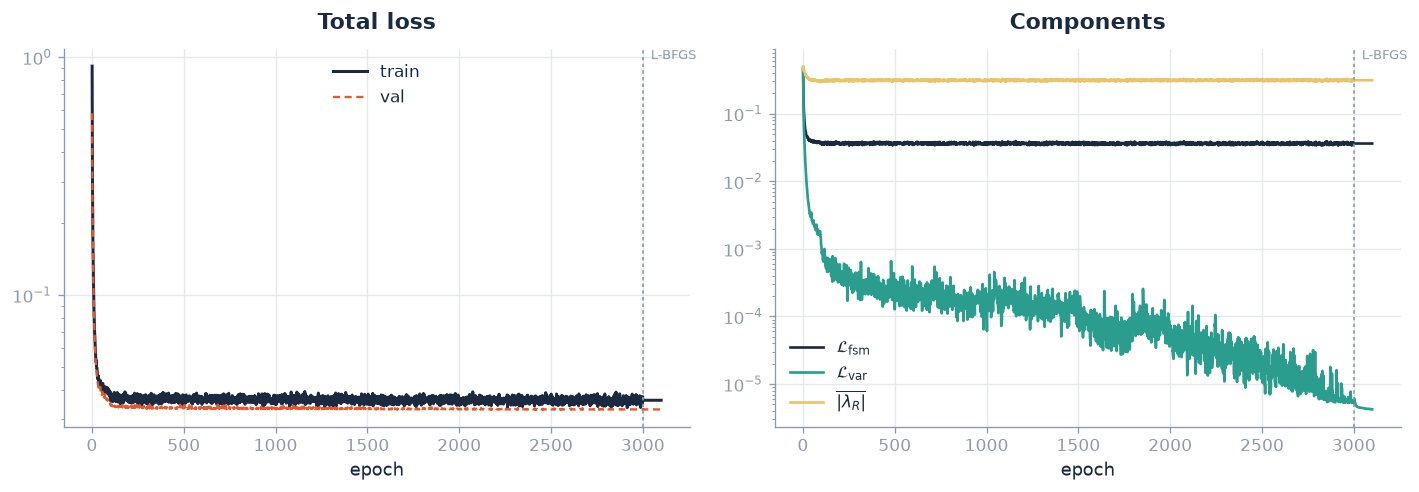

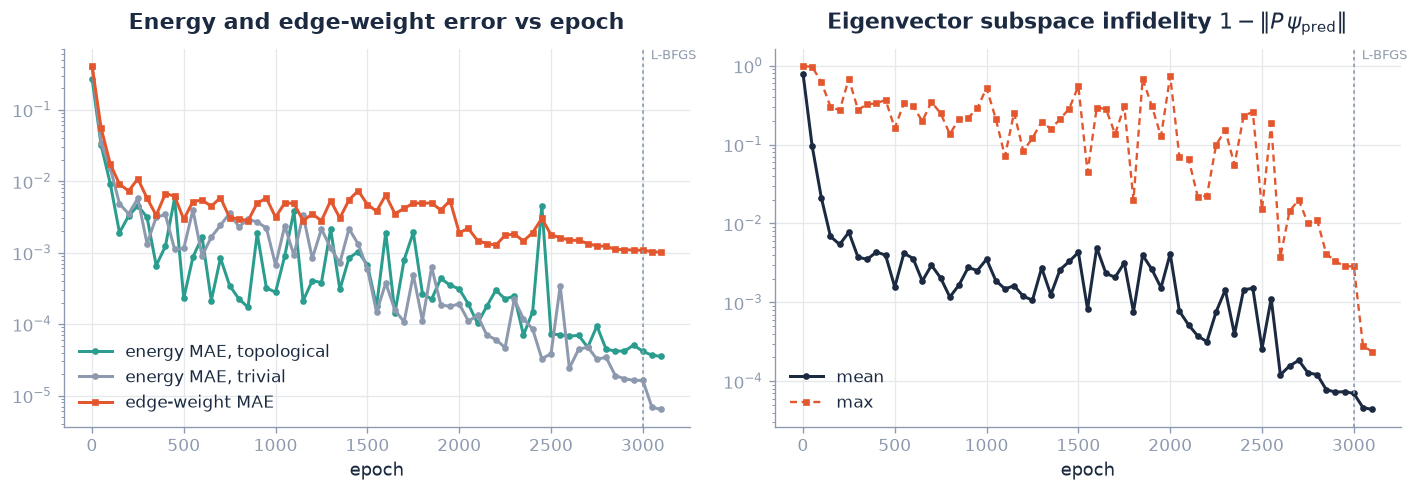

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)
split = TWO_PHASE.adam_epochs  # AdamW -> L-BFGS hand-over


def _mark_phase_split(ax, top=True):
    ax.axvline(split, color=SLATE, ls=(0, (2, 2)), lw=1.0)
    ax.text(
        split,
        ax.get_ylim()[1] if top else ax.get_ylim()[0],
        "  L-BFGS",
        ha="left",
        va="top" if top else "bottom",
        fontsize=8,
        color=SLATE,
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(epochs, history["train_loss"], color=INK, lw=1.8, label="train")
if "val_loss" in history:
    axes[0].plot(
        epochs, history["val_loss"], color=CORAL, lw=1.4, ls=(0, (3, 2)), label="val"
    )
axes[0].set_yscale("log")
axes[0].set_title("Total loss")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    epochs, history["train_fsm"], color=INK, lw=1.6, label=r"$\mathcal{L}_{\rm fsm}$"
)
axes[1].plot(
    epochs, history["train_var"], color=TEAL, lw=1.6, label=r"$\mathcal{L}_{\rm var}$"
)
# lam_mean is already the batch mean of |lambda_R| (branch-resolved metric).
axes[1].plot(
    epochs,
    history["train_lam_mean"],
    color=GOLD,
    lw=1.6,
    label=r"$\overline{|\lambda_R|}$",
)
axes[1].set_yscale("log")
axes[1].set_title("Components")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "loss_history.png", bbox_inches="tight")

# --- Figure 2: physical errors recorded by the probe --------------------------
p_epoch = np.asarray(history["probe_epoch"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    p_epoch,
    history["probe_e_mae_topological"],
    color=TEAL,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, topological",
)
axes[0].plot(
    p_epoch,
    history["probe_e_mae_trivial"],
    color=SLATE,
    lw=1.8,
    marker="o",
    ms=3,
    label="energy MAE, trivial",
)
axes[0].plot(
    p_epoch,
    history["probe_edge_mae"],
    color=CORAL,
    lw=1.8,
    marker="s",
    ms=3,
    label="edge-weight MAE",
)
axes[0].set_yscale("log")
axes[0].set_title("Energy and edge-weight error vs epoch")
axes[0].set_xlabel("epoch")
_mark_phase_split(axes[0])
axes[0].legend()

axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity"],
    color=INK,
    lw=1.8,
    marker="o",
    ms=3,
    label="mean",
)
axes[1].plot(
    p_epoch,
    history["probe_subspace_infidelity_max"],
    color=CORAL,
    lw=1.4,
    ls=(0, (3, 2)),
    marker="s",
    ms=3,
    label="max",
)
axes[1].set_yscale("log")
axes[1].set_title(r"Eigenvector subspace infidelity $1 - \|P\,\psi_{\rm pred}\|$")
axes[1].set_xlabel("epoch")
_mark_phase_split(axes[1])
axes[1].legend()

fig.tight_layout()
fig.savefig(session.path() / "probe_history.png", bbox_inches="tight")

### B. Lowest eigenvalue

Figure 3 compares the predicted lowest non-negative eigenvalue with exact
diagonalisation across $\mu \in [0, 4t]$. The prediction reproduces the
near-zero mode throughout the topological phase and the linear approach
$E \to |\mu| - 2t$ in the trivial phase. The inset shows the absolute error on
a logarithmic scale; the mean absolute error is reported separately for the
two phases in the log output below the figure.

findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.
2026-08-27 20:09:58 | INFO | chiral-unsupervised | E(mu) MAE over [0, 4t]:        4.2595e-05
2026-08-27 20:09:58 | INFO | chiral-unsupervised | E MAE, topological (mu < 2t):  7.8695e-05
2026-08-27 20:09:58 | INFO | chiral-unsupervised | E MAE, trivial     (mu > 2t):  6.4946e-06


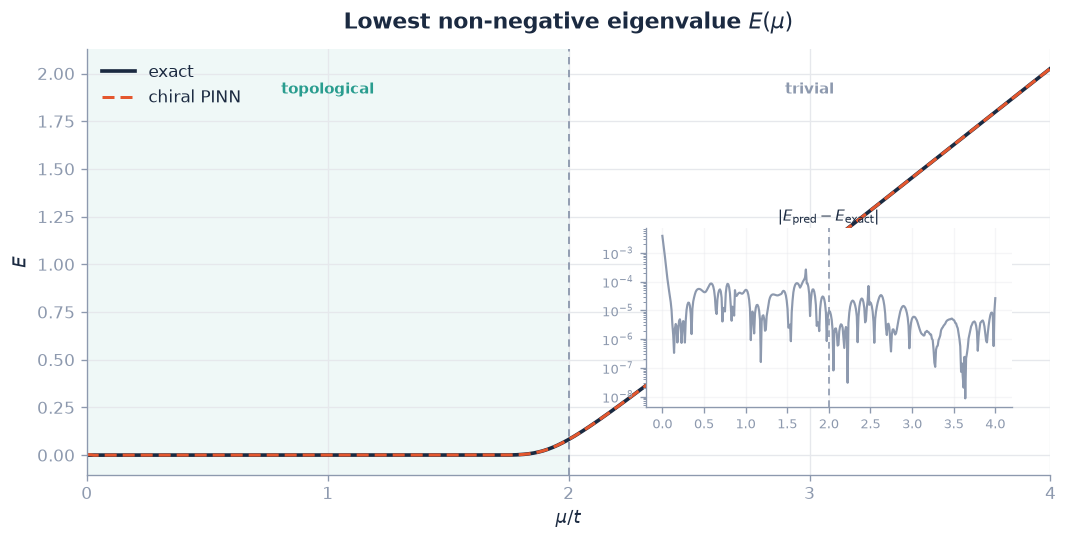

In [9]:
adapter = ChiralToBdGAdapter(trained_model, hopping=t, pairing=delta).to(
    accelerator.device
)
adapter.eval()

mu_sweep = np.linspace(0.0, 4.0, 400)
with torch.no_grad():
    mu_tensor = torch.tensor(
        mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_pred_t, psi_pred_t = adapter(mu_tensor)
# The adapter branch-resolves lambda_R, so e_pred is already >= 0.
e_pred = e_pred_t.cpu().numpy().ravel()
psi_pred = psi_pred_t.cpu().numpy()

e_exact = np.array(
    [np.linalg.eigvalsh(hamiltonian.build(float(m)))[N] for m in mu_sweep]
)
abs_err = np.abs(e_pred - e_exact)

fig, ax = plt.subplots(figsize=(9, 4.6))
_mark_topological(ax, t, 4.0)
ax.plot(mu_sweep, e_exact, color=INK, lw=2.2, label="exact")
ax.plot(mu_sweep, e_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="chiral PINN")
ax.fill_between(mu_sweep, e_exact, e_pred, color=CORAL, alpha=0.12, lw=0)
ax.set_title(r"Lowest non-negative eigenvalue $E(\mu)$")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
_annotate_phases(ax, t, y=ax.get_ylim()[1] * 0.9)
ax.legend(loc="upper left")

inset = ax.inset_axes([0.58, 0.16, 0.38, 0.42])
inset.plot(mu_sweep, abs_err, color=SLATE, lw=1.3)
inset.axvline(2 * t, color=SLATE, ls=(0, (4, 3)), lw=1.0)
inset.set_yscale("log")
inset.set_title(r"$|E_{\rm pred} - E_{\rm exact}|$", fontsize=9, pad=4)
inset.tick_params(labelsize=8)
inset.grid(True, alpha=0.4)

fig.tight_layout()
fig.savefig(session.path() / "energy_sweep.png", bbox_inches="tight")

session.info(f"E(mu) MAE over [0, 4t]:        {abs_err.mean():.4e}")
session.info(f"E MAE, topological (mu < 2t):  {abs_err[mu_sweep < 2 * t].mean():.4e}")
session.info(f"E MAE, trivial     (mu > 2t):  {abs_err[mu_sweep > 2 * t].mean():.4e}")

### C. Eigenvector fidelity and edge localisation

Deep in the topological phase the pair $\pm\lambda_1$ is degenerate to below
floating-point precision, and `numpy.linalg.eigh` returns an arbitrary
rotation within the corresponding two-dimensional eigenspace; the overlap of
$\psi_{\mathrm{pred}}$ with a single such vector is consequently ill-defined.
The left panel of Fig. 4 therefore reports the norm of the projection of
$\psi_{\mathrm{pred}}$ onto the span of the two exact eigenvectors of smallest
$|E|$, denoted $\lVert P\,\psi_{\mathrm{pred}} \rVert$, which equals unity
whenever $\psi_{\mathrm{pred}}$ lies within that subspace. The right panel
shows the combined particle and hole weight on the two outermost sites at each
end of the chain, a gauge-invariant diagnostic that is close to unity for a
Majorana edge mode and small once the state delocalises in the trivial phase.
These are the final-model counterparts of the training curves in Fig. 2,
resolved in $\mu$ rather than in epoch.

2026-08-27 20:10:07 | INFO | chiral-unsupervised | mean subspace fidelity: 0.9999  (min 0.9965)
2026-08-27 20:10:07 | INFO | chiral-unsupervised | edge-weight MAE: 1.1434e-03


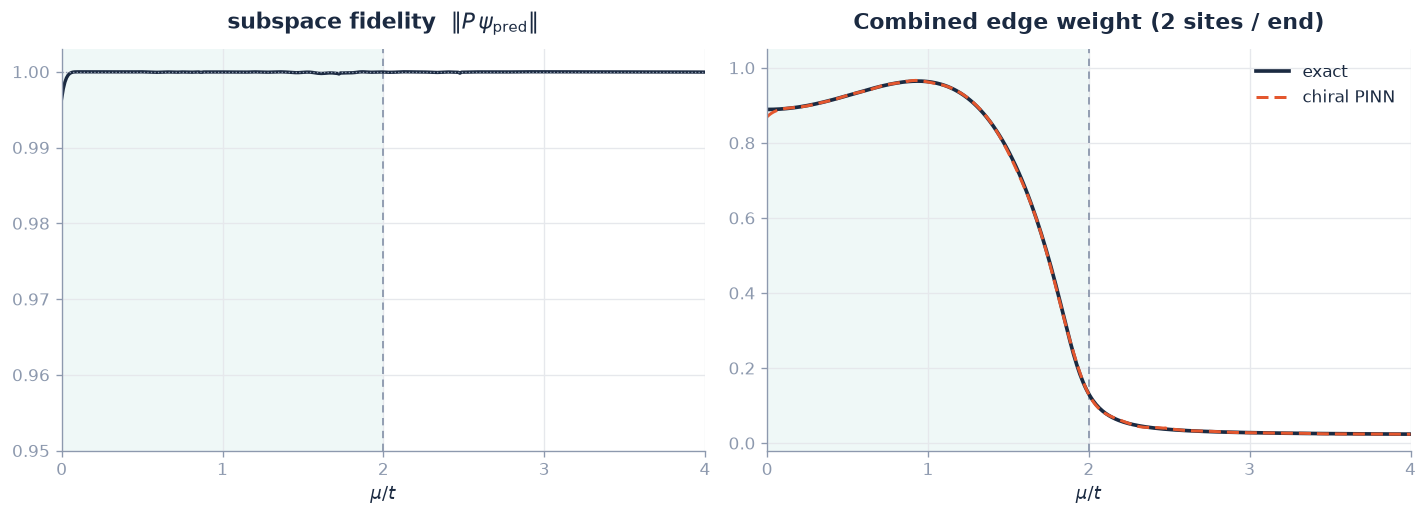

In [10]:
n_edge = 2
edge_idx = np.r_[0:n_edge, N - n_edge : N]

subspace_fidelity = np.empty_like(mu_sweep)
edge_exact = np.empty_like(mu_sweep)
for i, m in enumerate(mu_sweep):
    w, V = np.linalg.eigh(hamiltonian.build(float(m)))
    near_zero = V[:, np.argsort(np.abs(w))[:2]]  # the +/- lambda_min pair
    subspace_fidelity[i] = np.linalg.norm(near_zero.T @ psi_pred[i])
    psi_e = V[:, N]
    edge_exact[i] = (psi_e[:N][edge_idx] ** 2).sum() + (psi_e[N:][edge_idx] ** 2).sum()

prob_pred = psi_pred**2
edge_pred = prob_pred[:, :N][:, edge_idx].sum(1) + prob_pred[:, N:][:, edge_idx].sum(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

_mark_topological(axes[0], t, 4.0)
axes[0].plot(mu_sweep, subspace_fidelity, color=INK, lw=2.0)
axes[0].set_ylim(min(0.95, subspace_fidelity.min() - 0.01), 1.003)
axes[0].axhline(1.0, color=SLATE, lw=0.8, ls=":")
axes[0].set_title(r"subspace fidelity  $\|P\,\psi_{\rm pred}\|$")
axes[0].set_xlabel(r"$\mu / t$")

_mark_topological(axes[1], t, 4.0)
axes[1].plot(mu_sweep, edge_exact, color=INK, lw=2.2, label="exact")
axes[1].plot(
    mu_sweep, edge_pred, color=CORAL, lw=1.8, ls=(0, (4, 2)), label="chiral PINN"
)
axes[1].set_title("Combined edge weight (2 sites / end)")
axes[1].set_xlabel(r"$\mu / t$")
axes[1].set_ylim(-0.02, 1.05)
axes[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(session.path() / "eigenvector_agreement.png", bbox_inches="tight")

session.info(
    f"mean subspace fidelity: {subspace_fidelity.mean():.4f}  "
    f"(min {subspace_fidelity.min():.4f})"
)
session.info(f"edge-weight MAE: {np.abs(edge_pred - edge_exact).mean():.4e}")

### D. Probability densities

Figure 5 shows the particle- and hole-sector probability densities
$|\psi_n|^2$ as a function of site index at five representative values of
$\mu$: two deep in the topological phase ($\mu = 0.3\,t,\, 1.0\,t$), one at the
approach to the transition ($\mu = 1.9\,t$), and two in the trivial phase
($\mu = 2.6\,t,\, 3.4\,t$). The topological points exhibit the expected
localisation at both ends of the chain; the trivial points show an extended
bulk profile. The comparison is generated by the project's `sweep_wavefunctions`
routine, driven through the adapter.

Because the adapter fixes the branch, the split of $|\psi|^2$ between the
particle and hole sectors is now a meaningful comparison rather than a gauge
choice: an interchange of the two sectors relative to exact diagonalisation
in the trivial phase, which an unresolved network is free to produce, would
here indicate a genuine error. In the topological phase the two sectors carry
almost equal weight and the assignment is intrinsically ambiguous, so a
mismatch there is not significant.

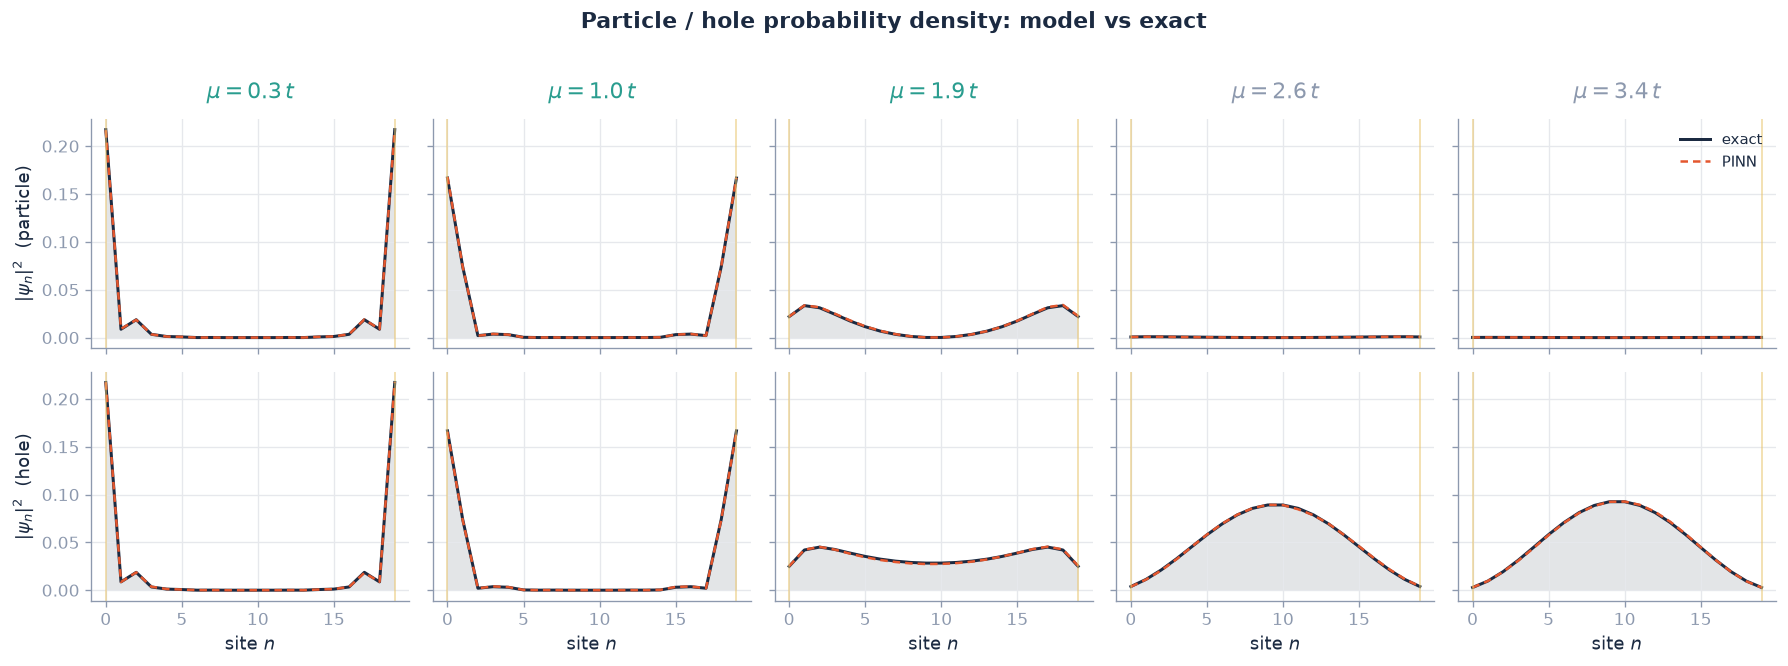

In [11]:
probe_mus = [0.3, 1.0, 1.9, 2.6, 3.4]
wf = sweep_wavefunctions(adapter, hamiltonian, probe_mus, device=accelerator.device)

fig, axes = plt.subplots(
    2, len(probe_mus), figsize=(3.0 * len(probe_mus), 5.4), sharex=True, sharey="row"
)
sites = wf.sites

for col, mu in enumerate(probe_mus):
    topo = mu < 2 * t
    tag_color = TEAL if topo else SLATE
    for row, (exact, pred, label) in enumerate(
        (
            (wf.particle_exact[col], wf.particle_pred[col], "particle"),
            (wf.hole_exact[col], wf.hole_pred[col], "hole"),
        )
    ):
        ax = axes[row, col]
        ax.fill_between(sites, exact, color=INK, alpha=0.12, lw=0)
        ax.plot(sites, exact, color=INK, lw=1.8, label="exact")
        ax.plot(sites, pred, color=CORAL, lw=1.5, ls=(0, (3, 2)), label="PINN")
        for edge in (0, N - 1):
            ax.axvline(edge, color=GOLD, lw=1.0, alpha=0.6)
        if row == 0:
            ax.set_title(rf"$\mu = {mu:.1f}\,t$", color=tag_color)
        if col == 0:
            ax.set_ylabel(rf"$|\psi_n|^2$  ({label})")
        if row == 1:
            ax.set_xlabel("site $n$")

axes[0, -1].legend(loc="upper right", fontsize=9)
fig.suptitle(
    "Particle / hole probability density: model vs exact",
    y=1.02,
    fontsize=13,
    weight="600",
)
fig.tight_layout()
fig.savefig(session.path() / "wavefunctions.png", bbox_inches="tight")

### E. Reflection symmetry

As a check of the construction of Sec. II E, the energy evaluated at $-\mu$
via the internal transform $u \to -D u$, $v \to D v$ is compared in Fig. 6
with the energy at $\mu$. The two agree to within the floating-point tolerance
of the forward pass, confirming that the spectrum is even in $\mu$ by
construction rather than as a learned property.

2026-08-27 20:25:13 | INFO | chiral-unsupervised | max |E(-mu) - E(mu)| via fold: 0.00e+00


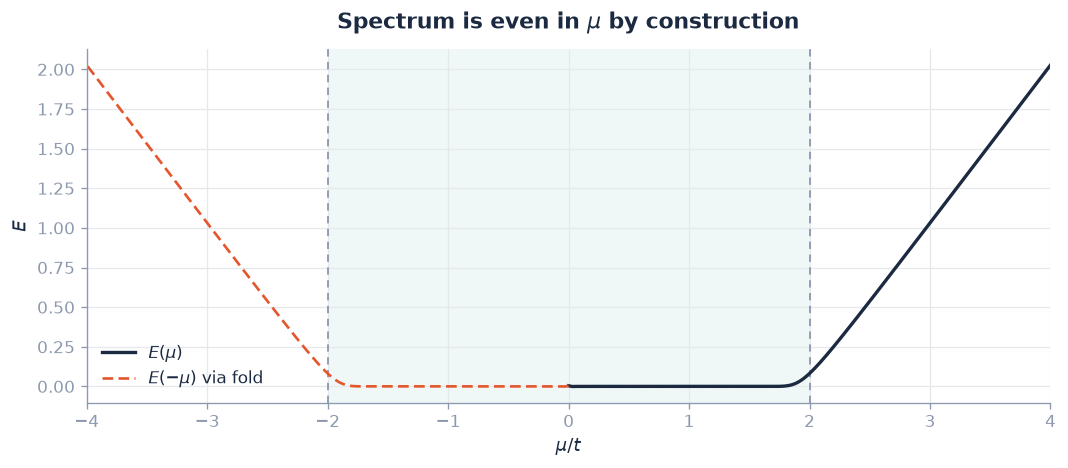

In [12]:
with torch.no_grad():
    mu_neg = torch.tensor(
        -mu_sweep[:, None], dtype=torch.float32, device=accelerator.device
    )
    e_neg = adapter(mu_neg)[0].cpu().numpy().ravel()

fig, ax = plt.subplots(figsize=(9, 4.0))
ax.axvline(2 * t, color=SLATE, ls=(0, (4, 3)), lw=1.1)
ax.axvline(-2 * t, color=SLATE, ls=(0, (4, 3)), lw=1.1)
ax.axvspan(-2 * t, 2 * t, color=TEAL, alpha=0.07, lw=0)
ax.plot(mu_sweep, e_pred, color=INK, lw=2.0, label=r"$E(\mu)$")
ax.plot(
    -mu_sweep, e_neg, color=CORAL, lw=1.6, ls=(0, (4, 2)), label=r"$E(-\mu)$ via fold"
)
ax.set_title(r"Spectrum is even in $\mu$ by construction")
ax.set_xlabel(r"$\mu / t$")
ax.set_ylabel(r"$E$")
ax.set_xlim(-4, 4)
ax.legend()
fig.tight_layout()
fig.savefig(session.path() / "mu_reflection.png", bbox_inches="tight")

session.info(f"max |E(-mu) - E(mu)| via fold: {np.abs(e_neg - e_pred).max():.2e}")

## VIII. Alternative sampling strategies

The experimental run of Secs. VI--VII fixes the optimiser to the two-stage
AdamW/L-BFGS schedule and the sampler to `mode="infinite"`. Both choices are
made through configuration objects and may be varied without modification of
either the network or the loss; together with the network capacity they
constitute the axes of the accompanying ablation study.

The sampling scheme is set by `SamplingConfig.mode`. The `frozen` mode
pre-generates a pool of collocation points and reshuffles it each epoch,
which is the cheapest option but exposes the residual to a fixed point set.
The `infinite` mode used above draws a fresh batch at every optimiser step,
so that the residual is never evaluated twice on the same grid. The
`curriculum` mode advances the active region mixture through a sequence of
stages keyed to the epoch number, which allows the network to establish a
consistent $(u,v)$ gauge on the topological interior before the dense
trivial-phase spectrum is introduced. The `adaptive` mode implements
residual-adaptive refinement: at fixed epoch intervals the per-point residual
of the current model is evaluated on a candidate pool, and the points of
largest residual are folded back into the sampling distribution, concentrating
subsequent effort where the model is least accurate. For all three streaming
modes a training epoch comprises `steps_per_epoch` optimiser steps.

The cell below constructs each alternative sampler so that its configuration
is documented alongside the baseline; the ablation notebook runs them under a
common protocol and reports the resulting accuracy.

In [ ]:
# --- frozen pool: cheapest, fixed collocation grid -------------------------
frozen_loader, frozen_cbs = build_sampling(
    SamplingConfig(mode="frozen", batch_size=1024, total_samples=8192),
    CHIRAL_HALF_DOMAIN_REGIONS,
)

# --- curriculum: topological interior first, then the full domain ----------
curriculum_loader, curriculum_cbs = build_sampling(
    SamplingConfig(
        mode="curriculum",
        batch_size=1024,
        steps_per_epoch=8,
        curriculum_stages=[
            (1, (SamplingRegion(low=0.05, high=2.0, weight=1.0),)),
            (400, CHIRAL_HALF_DOMAIN_REGIONS),
        ],
    ),
    CHIRAL_HALF_DOMAIN_REGIONS,
)

# --- adaptive (RAR/RAD): refine on the worst residual every 200 epochs -----
adaptive_loader, adaptive_cbs = build_sampling(
    SamplingConfig(
        mode="adaptive",
        batch_size=1024,
        steps_per_epoch=8,
        n_sites=N,
        hopping=t,
        pairing=delta,
        refine_every=200,
        candidate_pool=8192,
        keep_fraction=0.25,
        adaptive_fraction=0.5,
        domain=(0.05, 4.0),
    ),
    CHIRAL_HALF_DOMAIN_REGIONS,
)

for name, loader, cbs in (
    ("frozen", frozen_loader, frozen_cbs),
    ("curriculum", curriculum_loader, curriculum_cbs),
    ("adaptive", adaptive_loader, adaptive_cbs),
):
    first = next(iter(loader))[0]
    session.info(f"{name:11s}: batch {tuple(first.shape)}, {len(cbs)} callback(s)")

## IX. Summary

By working in the Majorana basis, the normalisation of the eigenvector, the
$\pm E$ spectral pairing, the particle--hole partner relation, and the
evenness of the spectrum in $\mu$ are all rendered exact by construction, and
`resolve_singular_branch` fixes the remaining $(u,v) \to (u,-v)$ gauge so
that the energy is non-negative and the particle/hole assignment is
single-valued in $\mu$. The label-free objective consequently reduces to a
folded-spectrum residual and an eigenvector-consistency residual on the
$N \times N$ chiral block $h(\mu)$, Eqs. (8)--(10), with no relative weight
and no annealing schedule, and only the half-domain $\mu \in [0, 4t]$ need be
sampled.

The functional is minimised in two stages: AdamW under a cosine decay on
freshly drawn collocation batches carries the parameters into a
well-conditioned basin, and L-BFGS under a strong-Wolfe line search on a
fixed collocation pool then reduces the eigenvector-consistency residual
further by exploiting curvature information (Fig. 1). Because
$\mathcal{L}_{\mathrm{fsm}}$ sits on a nonzero floor set by the exact
spectrum, the total loss is visually flat over most of the run; the probe
curves of Fig. 2 show the energy, edge-weight, and eigenvector errors falling
by orders of magnitude across exactly those epochs, so the plateau is
convergence rather than a stall. The final-model agreement with exact
diagonalisation is quantified in Fig. 3 (energy, with the per-phase MAE in
the log output) and Fig. 5 (edge-localised densities), obtained without any
reference eigenpairs in the loss.

The principal limitation is that the single-triple parametrisation fixes only
the two-dimensional near-zero subspace in the topological phase (Fig. 4), not
an individual vector within it; recovery of the full $\mathrm{O}(N)$
singular-vector structure of the reduced operator is the natural extension.
The sampling and optimisation choices of Sec. VIII -- the collocation mode,
the optimiser schedule, and the network capacity -- are the subject of the
accompanying ablation study.